<a href="https://colab.research.google.com/github/kunal190399/Human-in-the-Loop-Flood-Risk-Prediction-for-Urban-Drainage-Networks/blob/main/Human_in_the_Loop_Flood_Risk_Prediction_for_Urban_Drainage_Networks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install networkx osmnx geopandas matplotlib scikit-learn umap-learn seaborn --quiet

import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.inspection import permutation_importance

print("All libraries loaded")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 1.5 MB/s eta 0:00:00
All libraries loaded


Network: 30 nodes (junctions), 56 edges (pipes)
Average degree: 3.7 connections per node


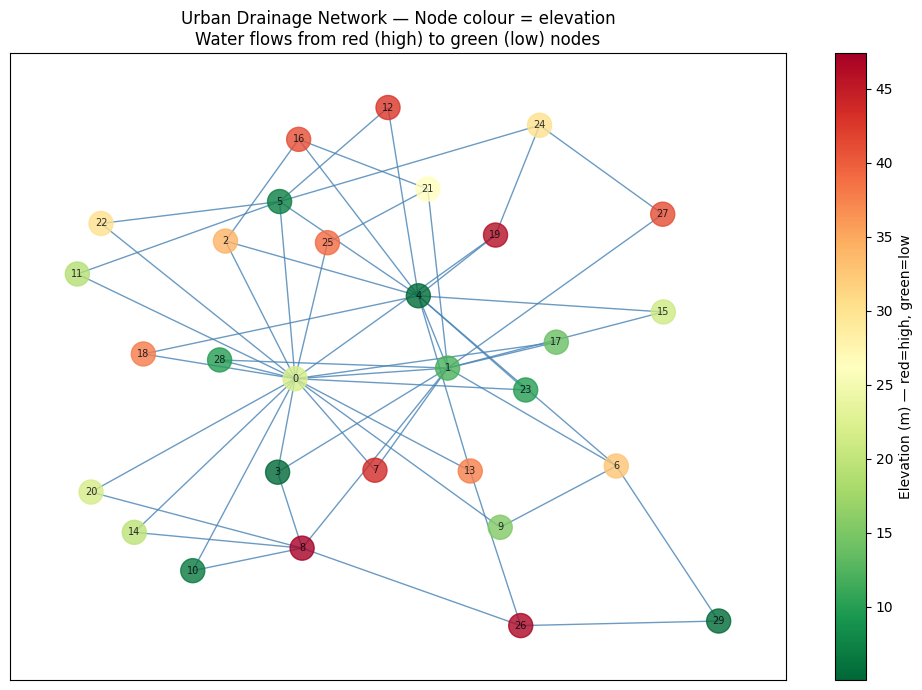

Network saved


In [2]:
# ── What are we doing? ───────────────────────────────────────────
# A sewer system is a GRAPH — pipes are edges, junctions are nodes.
# Each node has physical properties (elevation, pipe diameter, etc).
# We simulate a small urban catchment with 30 nodes and 40 pipes.
# This is exactly how physics-informed GNNs model sewer networks.

np.random.seed(42)
n_nodes = 30

# Create a random graph representing pipe connections
G = nx.barabasi_albert_graph(n_nodes, 2, seed=42)

# Assign physical properties to each node (junction)
for node in G.nodes():
    G.nodes[node]['elevation']      = np.random.uniform(5, 50)
    # Elevation in metres — water flows downhill
    G.nodes[node]['pipe_diameter']  = np.random.choice([0.3, 0.45, 0.6, 0.9])
    # Pipe diameter in metres — bigger = more capacity
    G.nodes[node]['catchment_area'] = np.random.uniform(0.5, 5.0)
    # Area draining into this node in hectares
    G.nodes[node]['impermeability'] = np.random.uniform(0.3, 0.95)
    # 0=permeable (soil absorbs water), 1=impermeable (all runs off)
    G.nodes[node]['age_years']      = np.random.randint(5, 80)
    # Older pipes = more likely to fail or have reduced capacity

# Assign rainfall scenarios to edges (pipes)
for u, v in G.edges():
    G[u][v]['flow_capacity'] = G.nodes[u]['pipe_diameter'] ** 2 * np.pi / 4
    # Physics: pipe capacity = cross-sectional area

print(f"Network: {G.number_of_nodes()} nodes (junctions), {G.number_of_edges()} edges (pipes)")
print(f"Average degree: {np.mean([d for _, d in G.degree()]):.1f} connections per node")

# Visualise the network
fig, ax = plt.subplots(figsize=(10, 7))
pos = nx.spring_layout(G, seed=42)
elevations = [G.nodes[n]['elevation'] for n in G.nodes()]
nx.draw_networkx(G, pos,
    node_color=elevations, cmap='RdYlGn_r',
    node_size=300, font_size=7,
    edge_color='steelblue', alpha=0.8, ax=ax)
sm = cm.ScalarMappable(cmap='RdYlGn_r',
    norm=plt.Normalize(min(elevations), max(elevations)))
plt.colorbar(sm, ax=ax, label='Elevation (m) — red=high, green=low')
ax.set_title('Urban Drainage Network — Node colour = elevation\n'
             'Water flows from red (high) to green (low) nodes')
plt.tight_layout()
plt.savefig('drainage_network.png', dpi=150, bbox_inches='tight')
plt.show()
print("Network saved")

In [3]:
# ── Scenario generation under uncertainty ───────────────────────
# Climate change makes rainfall unpredictable.
# We generate 500 rainfall scenarios varying:
#   - rainfall intensity (how hard it rains)
#   - duration (how long it rains)
#   - return period (how rare the event is — 1-in-10yr, 1-in-100yr etc)
# For each scenario we compute a FLOOD RISK SCORE per node.
# This is exactly what the PhD's scenario generation component does.

n_scenarios = 500

scenarios = pd.DataFrame({
    'rainfall_intensity':  np.random.gamma(2, 15, n_scenarios),
    # mm/hour — gamma distribution mimics real rainfall statistics
    'duration_hours':      np.random.exponential(3, n_scenarios),
    # hours — exponential distribution for storm duration
    'return_period_years': np.random.choice([2,5,10,25,50,100], n_scenarios),
    # How rare: 1-in-2yr to 1-in-100yr events
    'antecedent_moisture': np.random.uniform(0, 1, n_scenarios),
    # How wet the soil was before — affects runoff
    'climate_factor':      np.random.uniform(1.0, 1.4, n_scenarios),
    # Climate change multiplier: 1.0=present, 1.4=+40% future rainfall
})

print(f"Generated {n_scenarios} climate scenarios")
print("\nScenario statistics:")
print(scenarios.describe().round(2).to_string())

# ── Physics-informed flood risk calculation ───────────────────────
# This is a simplified hydraulic model — in reality GNNs learn this.
# Flood risk at a node depends on:
#   - how much rain falls on its catchment
#   - how impermeable the surface is
#   - the pipe capacity
#   - elevation (low nodes flood more)
#   - upstream contributions from connected nodes

node_features = pd.DataFrame([
    {
        'node': n,
        'elevation':      G.nodes[n]['elevation'],
        'pipe_diameter':  G.nodes[n]['pipe_diameter'],
        'catchment_area': G.nodes[n]['catchment_area'],
        'impermeability': G.nodes[n]['impermeability'],
        'age_years':      G.nodes[n]['age_years'],
        'degree':         G.degree(n),
        # Connectivity — more connections = more upstream inflow
    }
    for n in G.nodes()
])

# Compute flood risk for each node x scenario combination
results = []
for _, scenario in scenarios.iterrows():
    for _, node in node_features.iterrows():

        # Runoff volume = rainfall x area x impermeability x climate factor
        runoff = (scenario['rainfall_intensity'] *
                  scenario['duration_hours'] *
                  node['catchment_area'] *
                  node['impermeability'] *
                  scenario['climate_factor'] / 100)

        # Pipe capacity (simplified Manning's equation proxy)
        capacity = (node['pipe_diameter'] ** 2.67 *
                    max(0.01, 50 - node['elevation']) ** 0.5)

        # Flood risk score — higher = more likely to flood
        flood_risk = (runoff / (capacity + 0.001) *
                      (1 + scenario['antecedent_moisture']) *
                      np.log1p(scenario['return_period_years']) *
                      (1 + node['age_years'] / 100))

        results.append({
            **scenario.to_dict(),
            **node.to_dict(),
            'flood_risk': min(flood_risk, 10)  # cap at 10
        })

df = pd.DataFrame(results)
print(f"\nSimulation complete: {len(df):,} node-scenario combinations")
print(f"Flood risk range: {df['flood_risk'].min():.2f} to {df['flood_risk'].max():.2f}")
print(f"High risk events (>5): {(df['flood_risk']>5).sum():,} "
      f"({(df['flood_risk']>5).mean()*100:.1f}%)")

Generated 500 climate scenarios

Scenario statistics:
       rainfall_intensity  duration_hours  return_period_years  antecedent_moisture  climate_factor
count              500.00          500.00               500.00               500.00          500.00
mean                32.09            2.79                32.89                 0.50            1.21
std                 23.63            2.60                34.73                 0.30            0.12
min                  1.22            0.00                 2.00                 0.00            1.00
25%                 14.64            0.88                 5.00                 0.24            1.10
50%                 26.17            2.12                25.00                 0.52            1.21
75%                 44.63            3.58                50.00                 0.76            1.30
max                151.43           16.20               100.00                 1.00            1.40

Simulation complete: 15,000 node-scenario com

Training physics-informed flood risk model...
Model performance: RMSE = 0.886, R2 = 0.954


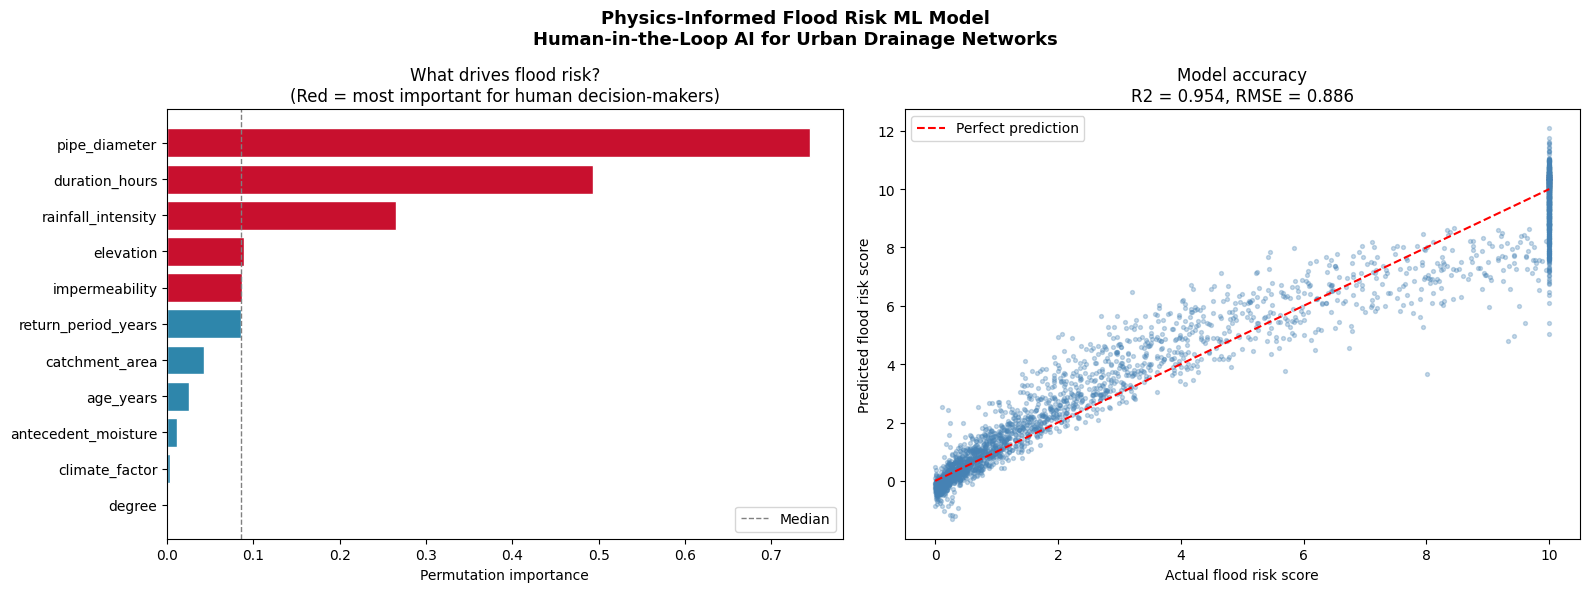

Model plot saved


In [4]:
# ── Physics-informed ML model ────────────────────────────────────
# We train a Gradient Boosting model to LEARN the flood risk function.
# In the real PhD, a GNN learns this from hydraulic simulation data.
# Key: we add SHAP-style feature importance for explainability.
# Explainability = humans can understand WHY the AI flags flood risk.

feature_cols = [
    'rainfall_intensity', 'duration_hours', 'return_period_years',
    'antecedent_moisture', 'climate_factor',
    'elevation', 'pipe_diameter', 'catchment_area',
    'impermeability', 'age_years', 'degree'
]

X = df[feature_cols].values
y = df['flood_risk'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print("Training physics-informed flood risk model...")
model = GradientBoostingRegressor(
    n_estimators=200, learning_rate=0.05,
    max_depth=5, random_state=42
)
model.fit(X_train_s, y_train)

y_pred = model.predict(X_test_s)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)
print(f"Model performance: RMSE = {rmse:.3f}, R2 = {r2:.3f}")

# ── Explainability — feature importance ───────────────────────────
# This is the Human-in-the-Loop component:
# We show WHICH factors drive flood risk so engineers can trust the AI.
importances = permutation_importance(
    model, X_test_s, y_test, n_repeats=10, random_state=42
)
imp_df = pd.DataFrame({
    'Feature':   feature_cols,
    'Importance': importances.importances_mean
}).sort_values('Importance', ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Physics-Informed Flood Risk ML Model\n'
             'Human-in-the-Loop AI for Urban Drainage Networks',
             fontsize=13, fontweight='bold')

# Left: Feature importance (explainability for engineers)
colors = ['#C8102E' if v > imp_df['Importance'].median()
          else '#2E86AB' for v in imp_df['Importance']]
axes[0].barh(imp_df['Feature'], imp_df['Importance'],
             color=colors, edgecolor='white')
axes[0].set_title('What drives flood risk?\n'
                  '(Red = most important for human decision-makers)')
axes[0].set_xlabel('Permutation importance')
axes[0].axvline(x=imp_df['Importance'].median(),
                color='gray', linestyle='--', linewidth=1,
                label='Median')
axes[0].legend()

# Right: Predicted vs actual
axes[1].scatter(y_test, y_pred, alpha=0.3, s=8, color='steelblue')
axes[1].plot([0,10], [0,10], 'r--', linewidth=1.5, label='Perfect prediction')
axes[1].set_xlabel('Actual flood risk score')
axes[1].set_ylabel('Predicted flood risk score')
axes[1].set_title(f'Model accuracy\nR2 = {r2:.3f}, RMSE = {rmse:.3f}')
axes[1].legend()

plt.tight_layout()
plt.savefig('flood_risk_model.png', dpi=150, bbox_inches='tight')
plt.show()
print("Model plot saved")

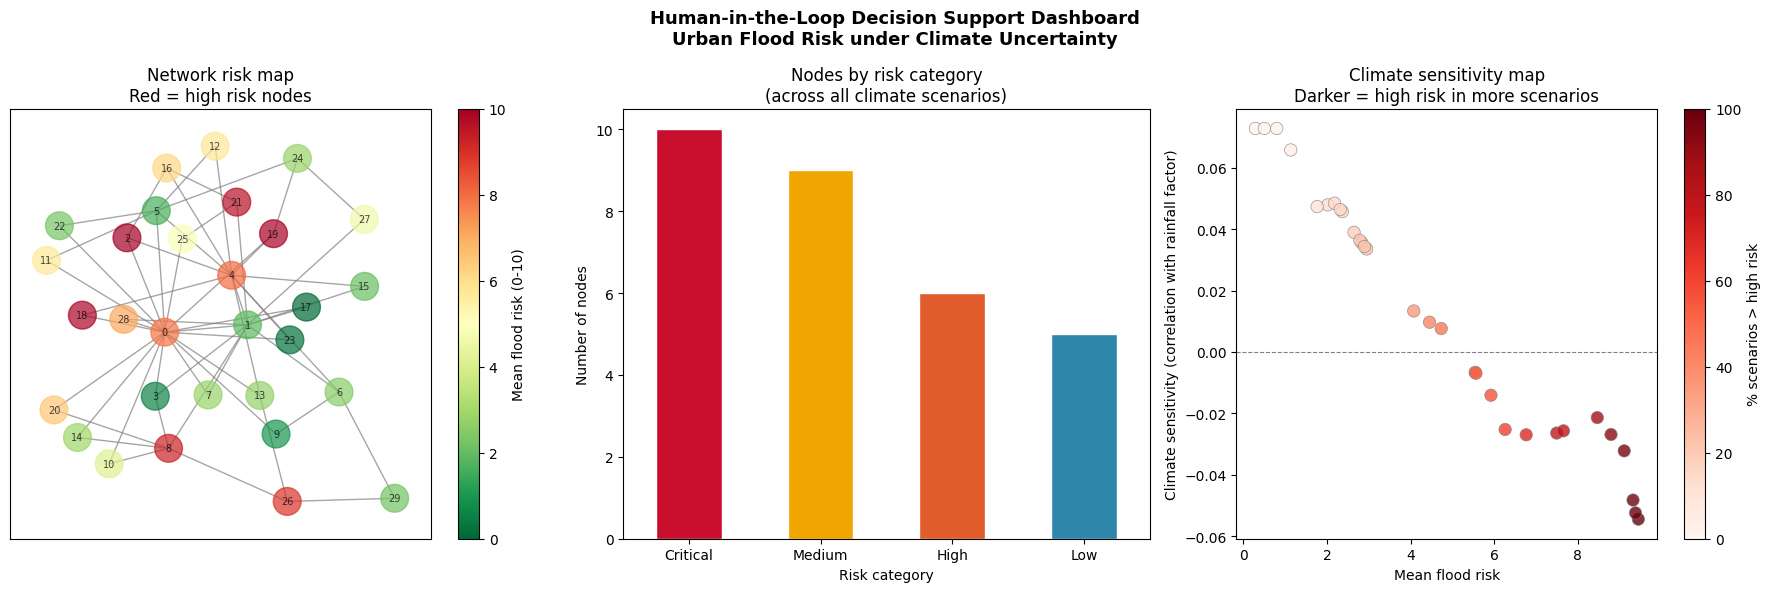


DECISION SUPPORT SUMMARY FOR ENGINEERS
Total nodes assessed  : 30
Critical risk nodes   : 10 (33%)
High risk nodes       : 6 (20%)

Top 5 most vulnerable nodes:
 node  mean_risk  max_risk  high_risk_pct  climate_sensitivity
  2.0       9.45      10.0           94.8                -0.05
 19.0       9.38      10.0           94.0                -0.05
 18.0       9.32      10.0           93.2                -0.05
 21.0       9.11      10.0           91.2                -0.03
  8.0       8.79      10.0           87.6                -0.03

Key finding: nodes with high climate sensitivity
should be prioritised for infrastructure upgrades
regardless of current risk level.


In [5]:
# ── This is the key contribution ─────────────────────────────────
# We generate a DECISION SUPPORT OUTPUT for human engineers.
# The AI flags high-risk nodes under different climate scenarios.
# Engineers can see: WHERE is at risk, WHY, and UNDER WHAT CONDITIONS.
# This is the human-in-the-loop alignment the PhD is building toward.

# Aggregate flood risk per node across all scenarios
node_risk = df.groupby('node').agg(
    mean_risk       = ('flood_risk', 'mean'),
    max_risk        = ('flood_risk', 'max'),
    high_risk_pct   = ('flood_risk', lambda x: (x > 5).mean() * 100),
    climate_sensitivity = ('climate_factor',
                          lambda x: df.loc[x.index, 'flood_risk'].corr(x))
).reset_index()

node_risk['risk_category'] = pd.cut(
    node_risk['mean_risk'],
    bins=[0, 2, 4, 6, 10],
    labels=['Low', 'Medium', 'High', 'Critical']
)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Human-in-the-Loop Decision Support Dashboard\n'
             'Urban Flood Risk under Climate Uncertainty',
             fontsize=13, fontweight='bold')

# Panel 1: Network coloured by flood risk
risk_vals = [node_risk[node_risk['node']==n]['mean_risk'].values[0]
             if n in node_risk['node'].values else 0
             for n in G.nodes()]
sc = nx.draw_networkx(G, pos,
    node_color=risk_vals, cmap='RdYlGn_r',
    node_size=400, font_size=7,
    edge_color='gray', alpha=0.7, ax=axes[0])
sm2 = cm.ScalarMappable(cmap='RdYlGn_r',
    norm=plt.Normalize(0, 10))
plt.colorbar(sm2, ax=axes[0], label='Mean flood risk (0-10)')
axes[0].set_title('Network risk map\nRed = high risk nodes')

# Panel 2: Risk category distribution
cat_counts = node_risk['risk_category'].value_counts()
colors_cat = {'Low':'#2E86AB', 'Medium':'#F0A500',
              'High':'#E05C2A', 'Critical':'#C8102E'}
cat_counts.plot(kind='bar', ax=axes[1],
    color=[colors_cat.get(c, 'gray') for c in cat_counts.index],
    edgecolor='white')
axes[1].set_title('Nodes by risk category\n(across all climate scenarios)')
axes[1].set_xlabel('Risk category')
axes[1].set_ylabel('Number of nodes')
axes[1].tick_params(axis='x', rotation=0)

# Panel 3: Climate sensitivity — which nodes worsen most with climate change
axes[2].scatter(
    node_risk['mean_risk'],
    node_risk['climate_sensitivity'],
    c=node_risk['high_risk_pct'],
    cmap='Reds', s=80, alpha=0.8, edgecolors='gray', linewidth=0.5
)
sm3 = cm.ScalarMappable(cmap='Reds',
    norm=plt.Normalize(0, 100))
plt.colorbar(sm3, ax=axes[2], label='% scenarios > high risk')
axes[2].set_xlabel('Mean flood risk')
axes[2].set_ylabel('Climate sensitivity (correlation with rainfall factor)')
axes[2].set_title('Climate sensitivity map\nDarker = high risk in more scenarios')
axes[2].axhline(y=0, color='gray', linestyle='--', linewidth=0.8)

plt.tight_layout()
plt.savefig('hitl_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

# Print human-readable summary for engineers
print("\n" + "="*60)
print("DECISION SUPPORT SUMMARY FOR ENGINEERS")
print("="*60)
critical = node_risk[node_risk['risk_category']=='Critical']
high     = node_risk[node_risk['risk_category']=='High']
print(f"Total nodes assessed  : {len(node_risk)}")
print(f"Critical risk nodes   : {len(critical)} "
      f"({len(critical)/len(node_risk)*100:.0f}%)")
print(f"High risk nodes       : {len(high)} "
      f"({len(high)/len(node_risk)*100:.0f}%)")
print(f"\nTop 5 most vulnerable nodes:")
top5 = node_risk.nlargest(5, 'mean_risk')[
    ['node','mean_risk','max_risk','high_risk_pct','climate_sensitivity']
].round(2)
print(top5.to_string(index=False))
print("\nKey finding: nodes with high climate sensitivity")
print("should be prioritised for infrastructure upgrades")
print("regardless of current risk level.")
print("="*60)